In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Tanushree\Downloads\finegrained-traceability-main\finegrained-traceability-main\datasets\iTrust\iTrust_gold.csv")

print(df.head())
print(df.columns)

         file          part  \
0  UC10E1.txt  UC10E1.txt.0   
1  UC10E2.txt  UC10E2.txt.0   
2  UC10E2.txt  UC10E2.txt.1   
3  UC10S1.txt  UC10S1.txt.0   
4  UC10S1.txt  UC10S1.txt.1   

                                                line  functional  Function  \
0  The health care professional types an invalid ...           1         1   
1      The patient chosen is not the desired patient           0         0   
2  The health care professional does not confirm ...           1         0   
3  The health care personnel enters a MID E of a ...           1         0   
4  The health care personnel may enteredit person...           1         1   

   Behavior  Data  OnlyF  F  OnlyQ  Q  UserRelated  
0         1     0      1  1      0  0            1  
1         0     0      0  0      0  0            0  
2         1     0      1  1      0  0            1  
3         0     0      1  1      0  0            1  
4         0     1      1  1      0  0            1  
Index(['file', 'part', 'li

In [2]:
print(df.columns)

Index(['file', 'part', 'line', 'functional', 'Function', 'Behavior', 'Data',
       'OnlyF', 'F', 'OnlyQ', 'Q', 'UserRelated'],
      dtype='object')


In [3]:
import os

path = r"C:\Users\Tanushree\Downloads\finegrained-traceability-main\finegrained-traceability-main\datasets\iTrust"

print(os.listdir(path))

['.ipynb_checkpoints', 'all_code_filenames.txt', 'all_req_filenames.txt', 'code', 'GNN_MODEL (2).ipynb', 'iTrust_best.csv', 'iTrust_gold.csv', 'itrust_method_callgraph.json', 'itrust_raw_callgraph.txt', 'itrust_solution_links.txt', 'metrics', 'preprocessed.csv', 'README.txt', 'req', 'req_preprocessed', 'XGBoost.ipynb']


In [4]:
import os

req_path = r"C:\Users\Tanushree\Downloads\finegrained-traceability-main\finegrained-traceability-main\datasets\iTrust\req"

req_files = os.listdir(req_path)

print(req_files[:5])

['UC10E1.txt', 'UC10E2.txt', 'UC10S1.txt', 'UC10S2.txt', 'UC11E1.txt']


In [5]:
import os

req_path = r"C:\Users\Tanushree\Downloads\finegrained-traceability-main\finegrained-traceability-main\datasets\iTrust\req"

req_data = {}

for file in os.listdir(req_path):
    file_path = os.path.join(req_path, file)

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        req_data[file] = f.read()

print("Total Requirements:", len(req_data))

first_key = list(req_data.keys())[0]

print("\nSample Requirement File:")
print(first_key)

print("\nRequirement Text Preview:")
print(req_data[first_key][:500])

Total Requirements: 131

Sample Requirement File:
UC10E1.txt

Requirement Text Preview:
The health care professional types an invalid medical identification number and is prompted to try again.



In [6]:
import os

code_path = r"C:\Users\Tanushree\Downloads\finegrained-traceability-main\finegrained-traceability-main\datasets\iTrust\code"

code_data = {}

for root, dirs, files in os.walk(code_path):

    for file in files:

        file_path = os.path.join(root, file)

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                code_data[file] = f.read()

        except Exception as e:
            print("Skipped:", file)

print("Total Code Files:", len(code_data))

sample_code = list(code_data.keys())[0]

print("\nSample Code File:")
print(sample_code)

print("\nCode Preview:")
print(code_data[sample_code][:500])

Total Code Files: 226

Sample Code File:
BeanBuilder.java

Code Preview:
package edu.ncsu.csc.itrust;

import java.beans.Introspector;
import java.beans.PropertyDescriptor;
import java.lang.reflect.Method;
import java.util.HashMap;
import java.util.Map;

/**
 * Takes a parameter map and creates a bean from that map of the appropriate type.
 * @param <T> The type to be returned from the appropriate parameter map.
 */
public class BeanBuilder<T> {
	/**
	 * The code here is not obvious, but this method should not need rewriting unless a bug is found
	 * 
	 * @param map 


In [7]:
import os

code_path = r"C:\Users\Tanushree\Downloads\finegrained-traceability-main\finegrained-traceability-main\datasets\iTrust\code"

code_data = {}

for root, dirs, files in os.walk(code_path):

    for file in files:

        file_path = os.path.join(root, file)

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                code_data[file] = f.read()

        except Exception as e:
            print("Skipped:", file, "| Error:", e)

print("Total Code Files:", len(code_data))

first_code = list(code_data.keys())[0]

print("\nSample Code File:")
print(first_code)

print("\nCode Preview:")
print(code_data[first_code][:500])

Total Code Files: 226

Sample Code File:
BeanBuilder.java

Code Preview:
package edu.ncsu.csc.itrust;

import java.beans.Introspector;
import java.beans.PropertyDescriptor;
import java.lang.reflect.Method;
import java.util.HashMap;
import java.util.Map;

/**
 * Takes a parameter map and creates a bean from that map of the appropriate type.
 * @param <T> The type to be returned from the appropriate parameter map.
 */
public class BeanBuilder<T> {
	/**
	 * The code here is not obvious, but this method should not need rewriting unless a bug is found
	 * 
	 * @param map 


In [8]:
links_path = r"C:\Users\Tanushree\Downloads\finegrained-traceability-main\finegrained-traceability-main\datasets\iTrust\itrust_solution_links.txt"

trace_links = []

with open(links_path, 'r', encoding='utf-8', errors='ignore') as f:

    for line in f:
        line = line.strip()

        if line:
            trace_links.append(line)

print("Total Trace Links:", len(trace_links))

print("\nSample Links:")
for link in trace_links[:10]:
    print(link)

Total Trace Links: 286

Sample Links:
UC10E1.txt: GetUserNameAction.java
UC10E1.txt: AuthDAO.java
UC10E2.txt: GetUserNameAction.java
UC10E2.txt: AuthDAO.java
UC10S1.txt: EditPHRAction.java
UC10S1.txt: PersonnelDAO.java
UC10S1.txt: HealthRecordsDAO.java
UC10S1.txt: OfficeVisitDAO.java
UC10S1.txt: FamilyDAO.java
UC10S1.txt: EditHealthHistoryAction.java


In [9]:
req_to_code = {}
code_to_req = {}

for link in trace_links:

    parts = link.split(": ")

    if len(parts) == 2:

        req, code = parts

        # Requirement -> Code
        if req not in req_to_code:
            req_to_code[req] = []

        req_to_code[req].append(code)

        # Code -> Requirement
        if code not in code_to_req:
            code_to_req[code] = []

        code_to_req[code].append(req)

print("Requirement to Code Example:")
sample_req = list(req_to_code.keys())[0]

print(sample_req)
print(req_to_code[sample_req])

print("\nCode to Requirement Example:")
sample_code = list(code_to_req.keys())[0]

print(sample_code)
print(code_to_req[sample_code])

Requirement to Code Example:
UC10E1.txt
['GetUserNameAction.java', 'AuthDAO.java']

Code to Requirement Example:
GetUserNameAction.java
['UC10E1.txt', 'UC10E2.txt', 'UC11E1.txt', 'UC11E2.txt', 'UC13E1.txt', 'UC19E1.txt', 'UC19E2.txt', 'UC21E1.txt', 'UC21E2.txt', 'UC23E1.txt', 'UC23E2.txt', 'UC23S1.txt', 'UC26E1.txt', 'UC26E2.txt', 'UC26S2.txt', 'UC26S3.txt', 'UC30E1.txt', 'UC30E2.txt', 'UC30S2.txt', 'UC34E1.txt', 'UC34S1.txt']


In [10]:
!pip install sentence-transformers

Defaulting to user installation because normal site-packages is not writeable


In [11]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
req_embeddings = {}

for req_file, req_text in req_data.items():

    embedding = model.encode(req_text)

    req_embeddings[req_file] = embedding

print("Generated Requirement Embeddings:", len(req_embeddings))

sample_req = list(req_embeddings.keys())[0]

print("\nSample Requirement:")
print(sample_req)

print("\nEmbedding Shape:")
print(req_embeddings[sample_req].shape)

Generated Requirement Embeddings: 131

Sample Requirement:
UC10E1.txt

Embedding Shape:
(384,)


In [13]:
code_embeddings = {}

for code_file, code_text in code_data.items():

    embedding = model.encode(code_text[:2000])

    code_embeddings[code_file] = embedding

print("Generated Code Embeddings:", len(code_embeddings))

sample_code = list(code_embeddings.keys())[0]

print("\nSample Code File:")
print(sample_code)

print("\nEmbedding Shape:")
print(code_embeddings[sample_code].shape)

Generated Code Embeddings: 226

Sample Code File:
BeanBuilder.java

Embedding Shape:
(384,)


In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sample_req = "UC10E1.txt"

req_vector = req_embeddings[sample_req]

similarities = {}

for code_file, code_vector in code_embeddings.items():

    score = cosine_similarity(
        [req_vector],
        [code_vector]
    )[0][0]

    similarities[code_file] = score

sorted_results = sorted(
    similarities.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Requirement:", sample_req)

print("\nTop Related Code Files:\n")

for code, score in sorted_results[:10]:
    print(code, "→", round(score, 4))

Requirement: UC10E1.txt

Top Related Code Files:

NoHealthRecordsException.java → 0.4255
TransactionType.java → 0.422
ViewPrescriptionRenewalNeedsAction.java → 0.3754
EditPrescriptionAction.java → 0.3725
UpdateNDCodeListAction.java → 0.3379
PersonnelBaseAction.java → 0.3368
PriorDiagnosisFactor.java → 0.3299
PatientBaseAction.java → 0.3193
Type1DiabetesRisks.java → 0.3139
OfficeVisitBaseAction.java → 0.3138


In [15]:
training_data = []

all_codes = list(code_embeddings.keys())

for req_file, req_vector in req_embeddings.items():

    linked_codes = req_to_code.get(req_file, [])

    for code_file in all_codes:

        code_vector = code_embeddings[code_file]

        similarity = cosine_similarity(
            [req_vector],
            [code_vector]
        )[0][0]

        label = 1 if code_file in linked_codes else 0

        training_data.append([
            req_file,
            code_file,
            similarity,
            label
        ])

print("Total Training Samples:", len(training_data))

print("\nSample Row:")
print(training_data[0])

Total Training Samples: 29606

Sample Row:
['UC10E1.txt', 'BeanBuilder.java', np.float32(-0.06216596), 0]


In [16]:
import pandas as pd

train_df = pd.DataFrame(
    training_data,
    columns=[
        "requirement",
        "code",
        "similarity",
        "label"
    ]
)

print(train_df.head())

print("\nDataset Shape:")
print(train_df.shape)

  requirement              code  similarity  label
0  UC10E1.txt  BeanBuilder.java   -0.062166      0
1  UC10E1.txt     DateUtil.java   -0.012775      0
2  UC10E1.txt       DBUtil.java    0.137907      0
3  UC10E1.txt    EmailUtil.java    0.045102      0
4  UC10E1.txt  HtmlEncoder.java    0.006784      0

Dataset Shape:
(29606, 4)


In [17]:
from sklearn.model_selection import train_test_split

X = train_df[["similarity"]]

y = train_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 23684
Testing Samples: 5922


In [18]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Training Complete!")

XGBoost Training Complete!


In [19]:
y_pred = xgb_model.predict(X_test)

print("Predictions Generated!")

Predictions Generated!


In [20]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.9894

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5859
           1       0.00      0.00      0.00        63

    accuracy                           0.99      5922
   macro avg       0.49      0.50      0.50      5922
weighted avg       0.98      0.99      0.98      5922



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
positive_df = train_df[train_df["label"] == 1]

negative_df = train_df[train_df["label"] == 0].sample(
    n=len(positive_df),
    random_state=42
)

balanced_df = pd.concat([positive_df, negative_df])

balanced_df = balanced_df.sample(frac=1, random_state=42)

print(balanced_df["label"].value_counts())

label
0    286
1    286
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features
X = balanced_df[["similarity"]]

# Labels
y = balanced_df["label"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

# Full Report
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.5478

Classification Report:

              precision    recall  f1-score   support

           0       0.52      0.56      0.54        54
           1       0.58      0.54      0.56        61

    accuracy                           0.55       115
   macro avg       0.55      0.55      0.55       115
weighted avg       0.55      0.55      0.55       115



In [23]:
req_text_map = req_data
code_text_map = code_data

enhanced_data = []

for req_file, req_vector in req_embeddings.items():

    linked_codes = req_to_code.get(req_file, [])

    req_text = req_text_map.get(req_file, "")

    for code_file, code_vector in code_embeddings.items():

        code_text = code_text_map.get(code_file, "")

        semantic_similarity = cosine_similarity(
            [req_vector],
            [code_vector]
        )[0][0]

        enhanced_data.append([
            req_file,
            code_file,
            req_text,
            code_text,
            semantic_similarity,
            1 if code_file in linked_codes else 0
        ])

print("Enhanced Dataset Size:", len(enhanced_data))

Enhanced Dataset Size: 29606


In [24]:
enhanced_df = pd.DataFrame(
    enhanced_data,
    columns=[
        "requirement",
        "code",
        "req_text",
        "code_text",
        "semantic_similarity",
        "label"
    ]
)

print(enhanced_df.head())

  requirement              code  \
0  UC10E1.txt  BeanBuilder.java   
1  UC10E1.txt     DateUtil.java   
2  UC10E1.txt       DBUtil.java   
3  UC10E1.txt    EmailUtil.java   
4  UC10E1.txt  HtmlEncoder.java   

                                            req_text  \
0  The health care professional types an invalid ...   
1  The health care professional types an invalid ...   
2  The health care professional types an invalid ...   
3  The health care professional types an invalid ...   
4  The health care professional types an invalid ...   

                                           code_text  semantic_similarity  \
0  package edu.ncsu.csc.itrust;\n\nimport java.be...            -0.062166   
1  package edu.ncsu.csc.itrust;\n\nimport java.te...            -0.012775   
2  package edu.ncsu.csc.itrust;\n\nimport java.sq...             0.137907   
3  package edu.ncsu.csc.itrust;\n\nimport edu.ncs...             0.045102   
4  package edu.ncsu.csc.itrust;\n\n/**\n * Escape...             0.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500)

combined_text = (
    enhanced_df["req_text"] + " " +
    enhanced_df["code_text"]
)

tfidf_matrix = vectorizer.fit_transform(combined_text)

print("TF-IDF Shape:", tfidf_matrix.shape)

TF-IDF Shape: (29606, 500)


In [26]:
from scipy.sparse import hstack
import scipy.sparse as sp

semantic_feature = sp.csr_matrix(
    enhanced_df[["semantic_similarity"]].values
)

combined_features = hstack([
    tfidf_matrix,
    semantic_feature
])

print("Combined Feature Shape:")
print(combined_features.shape)

Combined Feature Shape:
(29606, 501)


In [27]:
positive_df = enhanced_df[
    enhanced_df["label"] == 1
]

negative_df = enhanced_df[
    enhanced_df["label"] == 0
].sample(
    n=len(positive_df),
    random_state=42
)

balanced_df = pd.concat([
    positive_df,
    negative_df
])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
)

print(balanced_df["label"].value_counts())

label
0    286
1    286
Name: count, dtype: int64


In [28]:
balanced_indices = balanced_df.index

X = combined_features[balanced_indices]

y = balanced_df["label"]

print("Feature Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Shape: (572, 501)
Labels Shape: (572,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 457
Testing Samples: 115


In [30]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("Hybrid XGBoost Training Complete!")

Hybrid XGBoost Training Complete!


In [31]:
y_pred = xgb_model.predict(X_test)

print("Predictions Generated!")

Predictions Generated!


In [32]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Improved Accuracy:", round(accuracy, 4))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Improved Accuracy: 0.8783

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.91      0.88        54
           1       0.91      0.85      0.88        61

    accuracy                           0.88       115
   macro avg       0.88      0.88      0.88       115
weighted avg       0.88      0.88      0.88       115



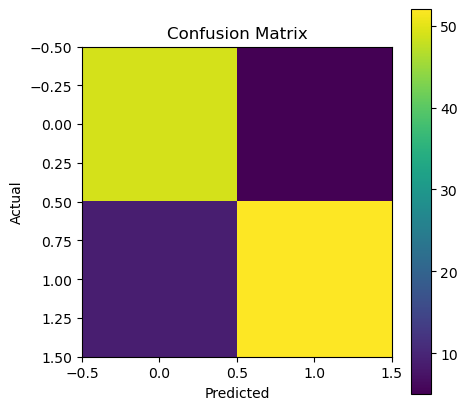

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [34]:
import json

callgraph_path = r"C:\Users\Tanushree\Downloads\finegrained-traceability-main\finegrained-traceability-main\datasets\iTrust\itrust_method_callgraph.json"

with open(callgraph_path, 'r', encoding='utf-8') as f:
    callgraph = json.load(f)

print("Total Call Graph Entries:", len(callgraph))

sample_key = list(callgraph.keys())[0]

print("\nSample Entry:")
print(sample_key)

print("\nConnected Methods:")
print(callgraph[sample_key][:5])

Total Call Graph Entries: 1235

Sample Entry:
BeanBuilder.build(Map,Object)

Connected Methods:


KeyError: slice(None, 5, None)

In [35]:
print(type(callgraph))

print("\nSample Key:")
print(sample_key)

print("\nType of Sample Entry:")
print(type(callgraph[sample_key]))

print("\nActual Sample Entry:")
print(callgraph[sample_key])

<class 'dict'>

Sample Key:
BeanBuilder.build(Map,Object)

Type of Sample Entry:
<class 'dict'>

Actual Sample Entry:
{'calls': ['BeanBuilder.checkOverloadedMethods(Object)'], 'called_by': [], 'class_name': 'BeanBuilder', 'method_name': 'build', 'params': ['Map', 'Object']}


In [36]:
def get_impacted_methods(changed_method):

    impacted = []

    if changed_method in callgraph:

        impacted.extend(
            callgraph[changed_method]["calls"]
        )

        impacted.extend(
            callgraph[changed_method]["called_by"]
        )

    return list(set(impacted))

In [37]:
sample_method = sample_key

print("Changed Method:")
print(sample_method)

print("\nPotentially Impacted Methods:\n")

impacted = get_impacted_methods(sample_method)

for method in impacted[:10]:
    print("-", method)

Changed Method:
BeanBuilder.build(Map,Object)

Potentially Impacted Methods:

- BeanBuilder.checkOverloadedMethods(Object)


In [39]:
def generate_impact_report(requirement_file):

    print("=" * 60)
    print("CHANGE IMPACT ANALYSIS REPORT")
    print("=" * 60)

    print("\nChanged Requirement:")
    print(requirement_file)

    print("\nDirectly Related Code Files:")

    related_codes = req_to_code.get(
        requirement_file,
        []
    )

    for code in related_codes:
        print("-", code)

    print("\nPotentially Impacted Methods:")

    impacted_methods = []

    for method in callgraph.keys():

        for code in related_codes:

            class_name = callgraph[method]["class_name"]

            if code.replace(".java", "") == class_name:

                impacted = get_impacted_methods(method)

                impacted_methods.extend(impacted)

    impacted_methods = list(set(impacted_methods))

    if impacted_methods:

        for method in impacted_methods[:15]:
            print("-", method)

    else:
        print("No impacted methods found.")

    print("\nTotal Impacted Methods:",
          len(impacted_methods))

    print("\nImpact Severity:")

    if len(impacted_methods) > 10:
        print("HIGH")

    elif len(impacted_methods) > 5:
        print("MEDIUM")

    else:
        print("LOW")

    print("=" * 60)

In [40]:
generate_impact_report("UC10E1.txt")

CHANGE IMPACT ANALYSIS REPORT

Changed Requirement:
UC10E1.txt

Directly Related Code Files:
- GetUserNameAction.java
- AuthDAO.java

Potentially Impacted Methods:
- AddPatientAction.addPatient(PatientBean)
- AuthDAO.insertLoginFailureRow(String,int,Connection)
- AuthDAO.getUserRole(long)
- AddPHAAction.add(PersonnelBean)
- PatientDAO.getName(long)
- ResetPasswordAction.getSecurityQuestion(long)
- AddHCPAction.add(PersonnelBean)
- DAOFactory.getConnection()
- AddRemoteMonitoringDataAction.addRemoteMonitoringData(int,int)
- SetSecurityQuestionAction.updateInformation(SecurityQA)
- AddOfficeVisitAction.getUserName()
- Role.toString()
- AddRemoteMonitoringDataAction.addRemoteMonitoringData(int,int,int)
- DAOFactory.getAuthDAO()
- PersonnelDAO.getName(long)

Total Impacted Methods: 47

Impact Severity:
HIGH
